# Winoground / Evaluating CLIP — Defensa MCC225
**Niels Pacheco** · C5, C8, C10

**Idea:** ¿CLIP *entiende* la escena o solo *empareja*?
**Tesis:** retrieval alto **≠** composición → Recall@K alto pero **group ≈ azar**.
Motor = OpenCLIP (C10); el *porqué* = fusión profunda (C5) y atención crossmodal (C8).

## 1. Entorno (trazabilidad)

In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name=='notebooks' else pathlib.Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
from src.env_logging import print_snapshot
_ = print_snapshot(ROOT)

/Users/nielspacheco/Desktop/Classes/UNI/Maestria en ciencias Computacion/IA generativa y multimodal/MCC225-ExamenParcial-Winoground/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HOJA DE TRAZABILIDAD — ENTORNO DE EJECUCIÓN (MCC225)
           python : 3.12.11
         platform : macOS-26.1-arm64-arm-64bit
     git_revision : e22ab9c
           device : mps (Apple Silicon)
            torch : 2.5.1
  open_clip_torch : 3.3.0
     transformers : 5.12.0
         datasets : 5.0.0
            numpy : 2.1.3
            faiss : 1.14.3


## 2. El par mínimo
2 imágenes + 2 captions con **las mismas palabras en otro orden**. Hay que entender *quién hace qué a quién*.

In [2]:
from src.winoground_data import load_dataset
examples, source = load_dataset(prefer_real=True)
print('fuente:', source, '| N =', len(examples))
ex = examples[0]
print('caption_0:', ex.caption_0); print('caption_1:', ex.caption_1)

fuente: winoground_real | N = 400
caption_0: an old person kisses a young person
caption_1: a young person kisses an old person


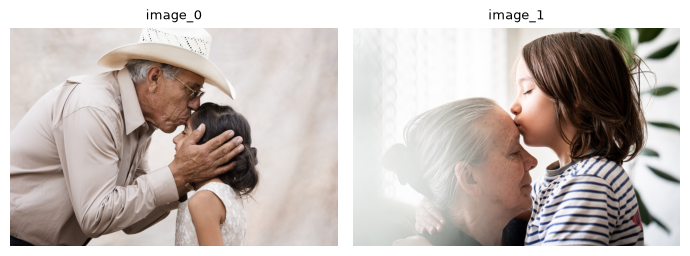

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(7, 3.2))
ax[0].imshow(ex.image_0); ax[0].set_title('image_0', fontsize=9); ax[0].axis('off')
ax[1].imshow(ex.image_1); ax[1].set_title('image_1', fontsize=9); ax[1].axis('off')
plt.tight_layout(); plt.show()

**3 métricas** (matriz `sim[caption, imagen]`): **text** (fija imagen, elige caption), **image** (fija caption, elige imagen), **group** (ambas). Azar: 1/4, 1/4, **1/6**.

## 3. Celda clave: el scorer
OpenCLIP (C10) → matriz 2×2 → 3 reglas. **Aquí sale el resultado.**

In [4]:
from src import openclip_utils as oc
from src.winoground_eval import text_correct, image_correct, group_correct
model, preprocess, tokenizer, device = oc.create_model('ViT-B-32','laion2b_s34b_b79k')
imgf = oc.encode_images(model, preprocess, [ex.image_0, ex.image_1], device)
capf = oc.encode_texts(model, tokenizer, [ex.caption_0, ex.caption_1], device)
sim = capf @ imgf.T   # sim[caption, imagen]
print('matriz 2x2:\n', sim.round(3))
print('text=', text_correct(sim), '| image=', image_correct(sim), '| group=', group_correct(sim))

matriz 2x2:
 [[0.343 0.329]
 [0.325 0.32 ]]
text= False | image= False | group= False


## 4. Validación del scorer
Aplico mi scorer a los scores de CLIP del paper (`clip.jsonl`): debe dar **0.3075 / 0.1050 / 0.0800**.

In [5]:
import json, re, numpy as np
from huggingface_hub import hf_hub_download
from src.winoground_eval import aggregate
try:
    p = hf_hub_download('facebook/winoground','statistics/model_scores/clip.jsonl',
                        repo_type='dataset', cache_dir='data/winoground_cache')
    sc = {}
    for line in open(p):
        r = json.loads(line); m = re.match(r'(\d+)_c(\d)_i(\d)', r['label'])
        eid,cc,ii = int(m[1]),int(m[2]),int(m[3]); sc.setdefault(eid, np.zeros((2,2)))[cc,ii]=r['score']
    agg = aggregate([sc[k] for k in sorted(sc)])
    print(f'mi scorer -> text={agg.text:.4f} image={agg.image:.4f} group={agg.group:.4f}  ✅')
except Exception as e:
    print('(dataset oficial no disponible:', type(e).__name__, ')')

mi scorer -> text=0.3075 image=0.1050 group=0.0800  ✅


## 5. Resultado principal (400 ejemplos)

In [6]:
import json, pandas as pd
MET = ROOT/'outputs'/'metrics'
scores = json.loads((MET/'scores.json').read_text())
print(scores['primary_checkpoint'], '| fuente:', scores['source'])
print(json.dumps(scores['scores'], indent=2))
pd.read_csv(MET/'bootstrap_ci.csv')

ViT-B-32 / laion2b | fuente: winoground_real
{
  "n_examples": 400,
  "text_score": 0.3475,
  "image_score": 0.11,
  "group_score": 0.075,
  "chance_text": 0.25,
  "chance_image": 0.25,
  "chance_group": 0.16666666666666666
}


,metric,mean,lo,hi,rounds,n,chance
0,text,0.3475,0.2999,0.3975,2000,400,0.2500
1,image,0.1100,0.0800,0.1425,2000,400,0.2500
2,group,0.0750,0.0500,0.1025,2000,400,0.1667


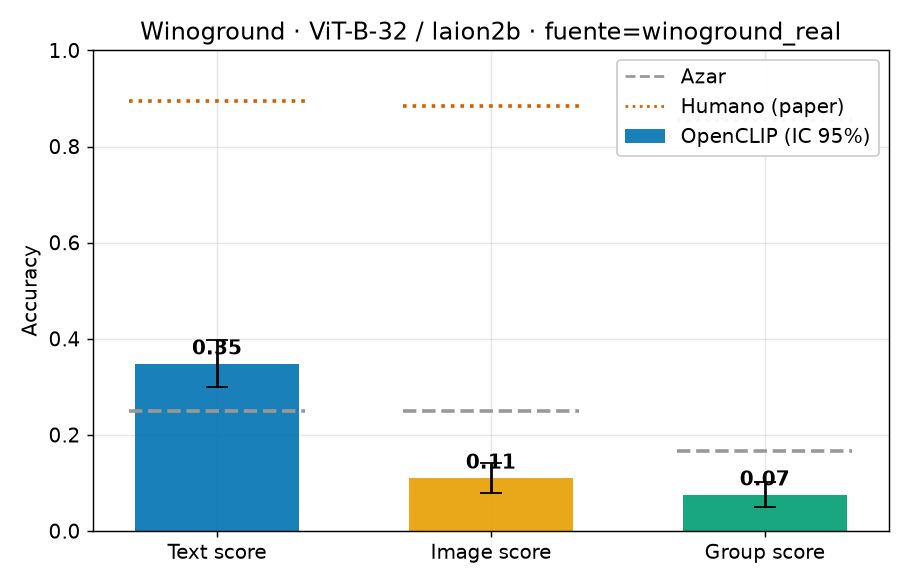

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT/'outputs'/'figures'/'scores_vs_chance.png')))

## 6. Tesis: retrieval alto vs group bajo

R@K texto->imagen: {'R@1': 0.30375, 'R@5': 0.6675, 'R@10': 0.77375}
group: 0.075 | azar: 0.1667


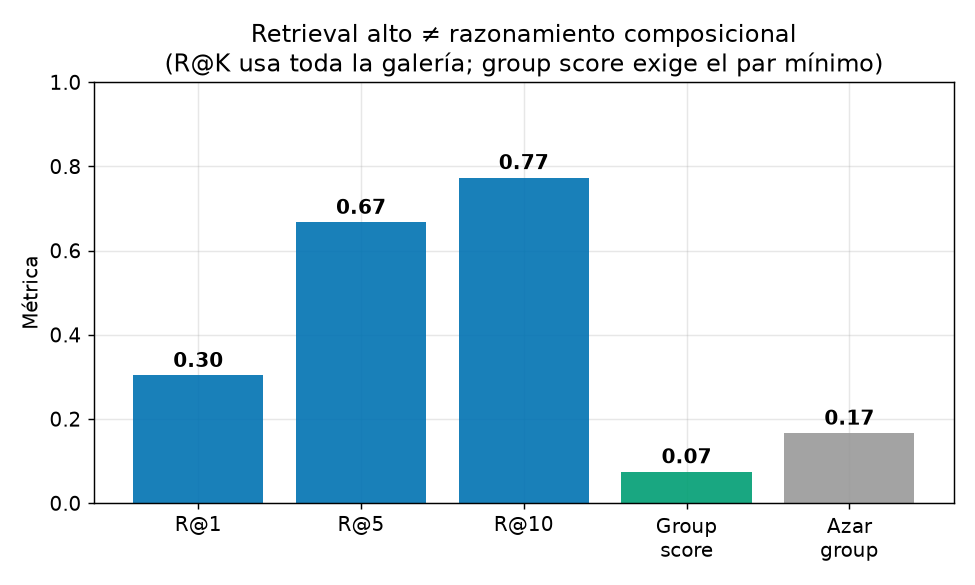

In [8]:
rg = json.loads((MET/'recall_vs_group.json').read_text())
print('R@K texto->imagen:', {k:v for k,v in rg['text_to_image_recall'].items() if k.startswith('R@')})
print('group:', rg['winoground_group_score'], '| azar:', rg['chance_group'])
display(Image(filename=str(ROOT/'outputs'/'figures'/'recall_vs_group.png')))

## 7. Por tag y prueba de ceguera (¿usa la imagen?)

In [9]:
display(pd.read_csv(MET/'by_tag.csv'))
b = json.loads((MET/'blindness.json').read_text())
print('real     :', {k:round(v,3) for k,v in b['real'].items() if 'score' in k})
print('permutado:', {k:round(v,3) for k,v in b['permuted_images'].items() if 'score' in k})

,tag,text,image,group,n
0,Relation,0.304721,0.090129,0.047210,233
1,Object,0.390071,0.106383,0.085106,141
2,Both,0.500000,0.307692,0.269231,26


real     : {'text_score': 0.347, 'image_score': 0.11, 'group_score': 0.075}
permutado: {'text_score': 0.135, 'image_score': 0.035, 'group_score': 0.015}


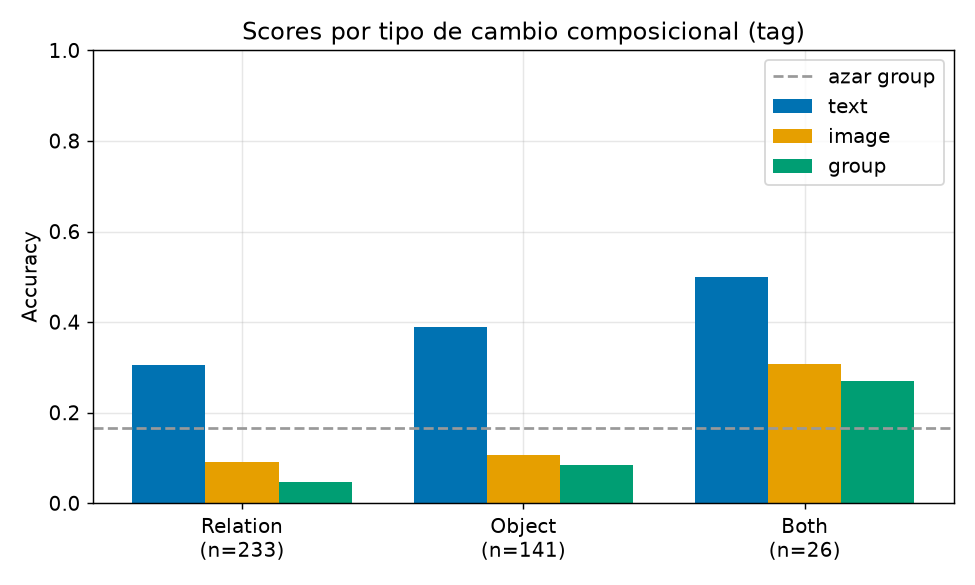

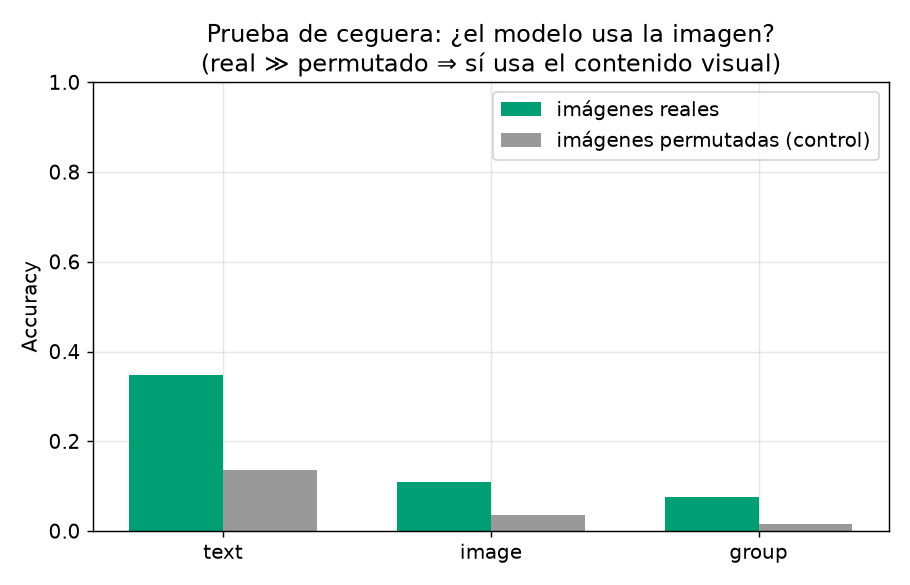

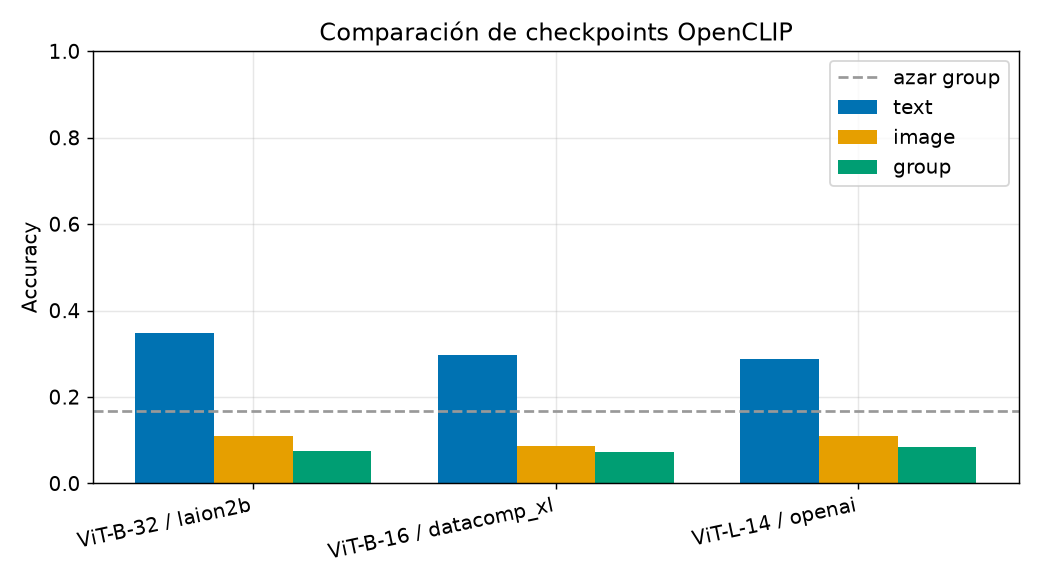

In [10]:
for n in ['by_tag.png','blindness.png','checkpoint_comparison.png']:
    display(Image(filename=str(ROOT/'outputs'/'figures'/n)))

## 8. Respuestas — 5 preguntas (8.6)

1. **Retrieval ≠ composición:** R@K busca en toda la galería (fácil); group exige el par mínimo (orden/relación). R@5=0.67 vs group=0.075. Un dual-encoder es *bolsa de conceptos* (C5).
2. **¿Usa la imagen?** Sí. Prueba de ceguera: al permutar imágenes los scores caen (0.35→0.14, 0.075→0.02). El límite es composicional, no perceptivo (C8).
3. **Tipo de error:** de *vinculación*, no de reconocimiento. **Relation** es lo peor (group ≈ 0.047).
4. **Adaptar el código:** cada ejemplo = `(img0,img1,cap0,cap1)`; para un par nuevo permuto dos tokens y aporto las imágenes. El scorer arma la matriz 2×2. Lo único nuevo vs C10 es el scorer.
5. **Límite de las métricas:** R@K/accuracy no miden composición; comparaciones estrictas (empates); azar group=1/6; el benchmark tiene ítems ambiguos (Diwan et al.).

## 9. Cierre
**C10** motor · **C5** por qué falla · **C8** interpretabilidad. **Limitación:** el group mezcla composición con ítems ambiguos. **Mejora:** cross-encoder (C5) + re-ranking (C6). **Conclusión:** retrieval alto **no** implica composición.